In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_parquet('../data/customer churn/clean_data.parquet')
data.head()

,gender,age,under_30,senior_citizen,partner,dependents,number_of_dependents,married,country,state,total_population,phone_service,internet_service,online_security,online_backup,device_protection,premium_tech_support,streaming_tv,streaming_movies,streaming_music,internet_type,contract,paperless_billing,payment_method,monthly_ charges,avg_monthly_long_distance_charges,total_charges,total_long_distance_charges,total_revenue,tenure,multiple_lines,avg_monthly_gb_download,unlimited_data,offer,referred_a_friend,satisfaction_score,cltv,churn_score,churn_label,churn_value,extra_data_charges,referrals
0,2,37,0,0,1,0,0,1,1,1,4498,1,1,0,1,0,1,1,0,0,3,3,1,2,65.6,42.39,593.30,381.51,974.81,9,0,16,1,2,1,3,2205,65,0,0,0,1
1,1,46,0,0,0,0,0,0,1,1,31297,1,1,0,0,0,0,0,1,1,3,1,0,2,59.9,10.69,542.40,96.21,610.28,9,1,10,0,2,0,5,5414,66,0,0,1,0
2,1,50,0,0,0,0,0,0,1,1,62069,1,1,0,0,1,0,0,0,0,1,1,1,1,73.9,33.65,280.85,134.60,415.45,4,0,30,1,2,0,1,4479,71,1,1,0,0
3,1,78,0,1,1,0,0,1,1,1,46677,1,1,0,1,1,0,1,1,0,1,1,1,1,98.0,27.82,1237.85,361.66,1599.51,13,0,4,1,3,1,1,3714,91,1,1,0,1
4,2,75,0,1,1,0,0,1,1,1,42853,1,1,0,0,0,1,1,0,0,1,1,1,2,83.9,7.38,267.40,22.14,289.54,3,0,11,1,3,1,1,3464,68,1,1,0,1


In [3]:
import json
with open('note.txt', 'r') as file:
    f = file.read()
    info = json.loads(f)
info

{'shape': [7043, 51],
 'gender': {'1': 'Male', '2': 'Female'},
 'country': {'1': 'United States'},
 'state': {'1': 'California'},
 'internet_type': {'1': 'Fiber Optic', '2': 'DSL', '3': 'Cable'},
 'contract': {'1': 'Month-to-Month', '2': 'Two Year', '3': 'One Year'},
 'payment_method': {'1': 'Electronic check',
  '2': 'Mailed check',
  '3': 'Bank transfer (automatic)',
  '4': 'Credit card (automatic)'},
 'offer': {'1': 'Offer B',
  '2': 'Offer E',
  '3': 'Offer D',
  '4': 'Offer A',
  '5': 'Offer C'},
 'extra_data_charges': {'0': 'not_paid', '1': 'paid'},
 'referrals': {'0': 'not_referred',
  '1': 'referred_less_than_5',
  '2': 'referred_more_than_5'},
 'clean_shape': [7017, 42]}

In [4]:
info['gender']['1']

'Male'

In [5]:
# what the point of age ?
# if under 30 we have under_30 col
# if above 65 we have senior_citizen col
# so if both 0 0 we can know it's between both 30<and<65
# therfore drop age
data.drop('age', axis=1, inplace=True)

Text(0.5, 1.0, 'Box Plot of cltv')

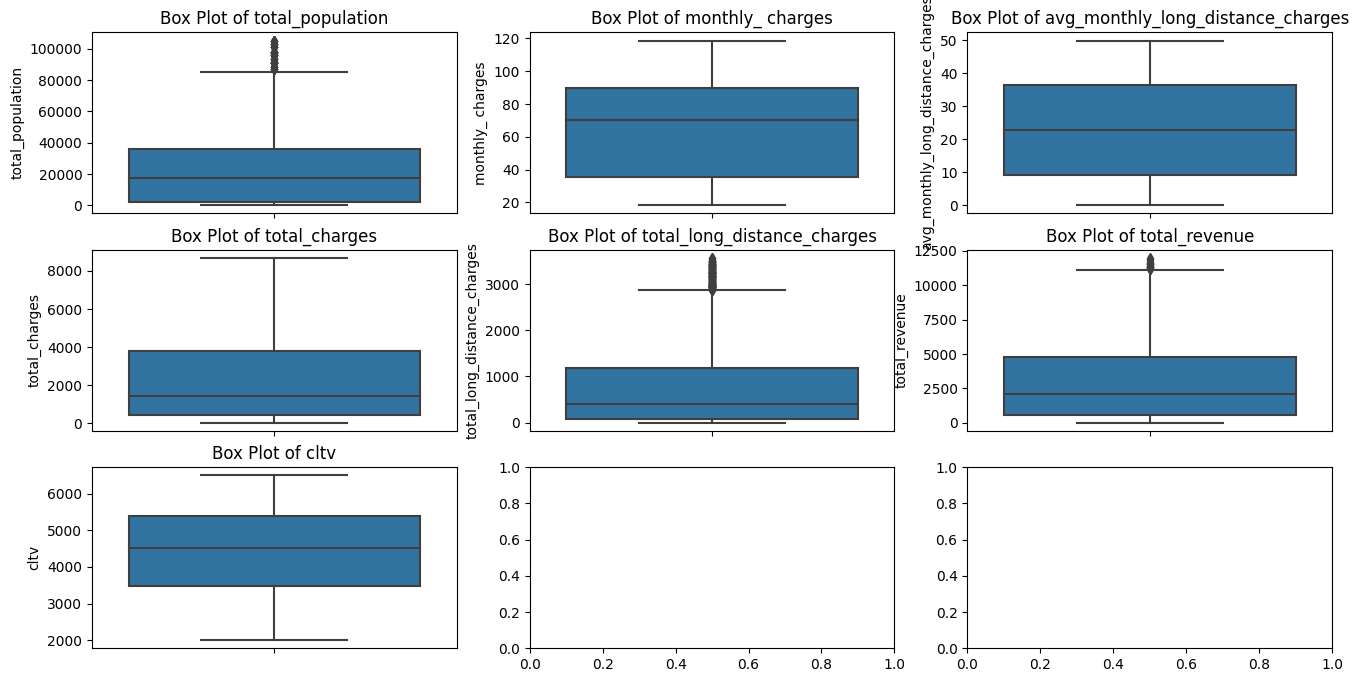

In [6]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 8))

sns.boxplot(y=data['total_population'], ax=axes[0,0])
axes[0,0].set_title('Box Plot of total_population')

sns.boxplot(y=data['monthly_ charges'], ax=axes[0,1])
axes[0,1].set_title('Box Plot of monthly_ charges')

sns.boxplot(y=data['avg_monthly_long_distance_charges'], ax=axes[0,2])
axes[0,2].set_title('Box Plot of avg_monthly_long_distance_charges')

sns.boxplot(y=data['total_charges'], ax=axes[1,0])
axes[1,0].set_title('Box Plot of total_charges')

sns.boxplot(y=data['total_long_distance_charges'], ax=axes[1,1])
axes[1,1].set_title('Box Plot of total_long_distance_charges')

sns.boxplot(y=data['total_revenue'], ax=axes[1,2])
axes[1,2].set_title('Box Plot of total_revenue')

sns.boxplot(y=data['cltv'], ax=axes[2,0])
axes[2,0].set_title('Box Plot of cltv')

In [7]:
# !pip install xgboost

In [8]:
# let's run directly first
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

In [9]:
data

,gender,under_30,senior_citizen,partner,dependents,number_of_dependents,married,country,state,total_population,phone_service,internet_service,online_security,online_backup,device_protection,premium_tech_support,streaming_tv,streaming_movies,streaming_music,internet_type,contract,paperless_billing,payment_method,monthly_ charges,avg_monthly_long_distance_charges,total_charges,total_long_distance_charges,total_revenue,tenure,multiple_lines,avg_monthly_gb_download,unlimited_data,offer,referred_a_friend,satisfaction_score,cltv,churn_score,churn_label,churn_value,extra_data_charges,referrals
0,2,0,0,1,0,0,1,1,1,4498,1,1,0,1,0,1,1,0,0,3,3,1,2,65.60,42.39,593.30,381.51,974.81,9,0,16,1,2,1,3,2205,65,0,0,0,1
1,1,0,0,0,0,0,0,1,1,31297,1,1,0,0,0,0,0,1,1,3,1,0,2,59.90,10.69,542.40,96.21,610.28,9,1,10,0,2,0,5,5414,66,0,0,1,0
2,1,0,0,0,0,0,0,1,1,62069,1,1,0,0,1,0,0,0,0,1,1,1,1,73.90,33.65,280.85,134.60,415.45,4,0,30,1,2,0,1,4479,71,1,1,0,0
3,1,0,1,1,0,0,1,1,1,46677,1,1,0,1,1,0,1,1,0,1,1,1,1,98.00,27.82,1237.85,361.66,1599.51,13,0,4,1,3,1,1,3714,91,1,1,0,1
4,2,0,1,1,0,0,1,1,1,42853,1,1,0,0,0,1,1,0,0,1,1,1,2,83.90,7.38,267.40,22.14,289.54,3,0,11,1,3,1,1,3464,68,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2,1,0,0,0,0,0,1,1,44652,1,1,1,0,0,1,0,0,1,2,3,0,2,55.15,46.68,742.90,606.84,1349.74,13,0,59,1,3,0,4,3161,59,0,0,0,0
7039,1,0,0,1,0,0,1,1,1,16525,1,1,0,0,0,0,0,1,1,1,1,1,1,85.10,16.20,1873.70,356.40,2230.10,22,1,17,1,3,1,1,5248,68,1,1,0,1
7040,1,1,0,0,0,0,0,1,1,383,1,1,0,1,0,0,0,0,0,2,1,1,2,50.30,18.62,92.75,37.24,129.99,2,0,51,1,2,0,5,5870,33,0,0,0,0
7041,1,1,0,1,0,0,1,1,1,12173,1,1,1,0,1,1,0,1,1,3,2,0,2,67.85,2.12,4627.65,142.04,4769.69,67,0,58,1,4,1,3,4792,59,0,0,0,2


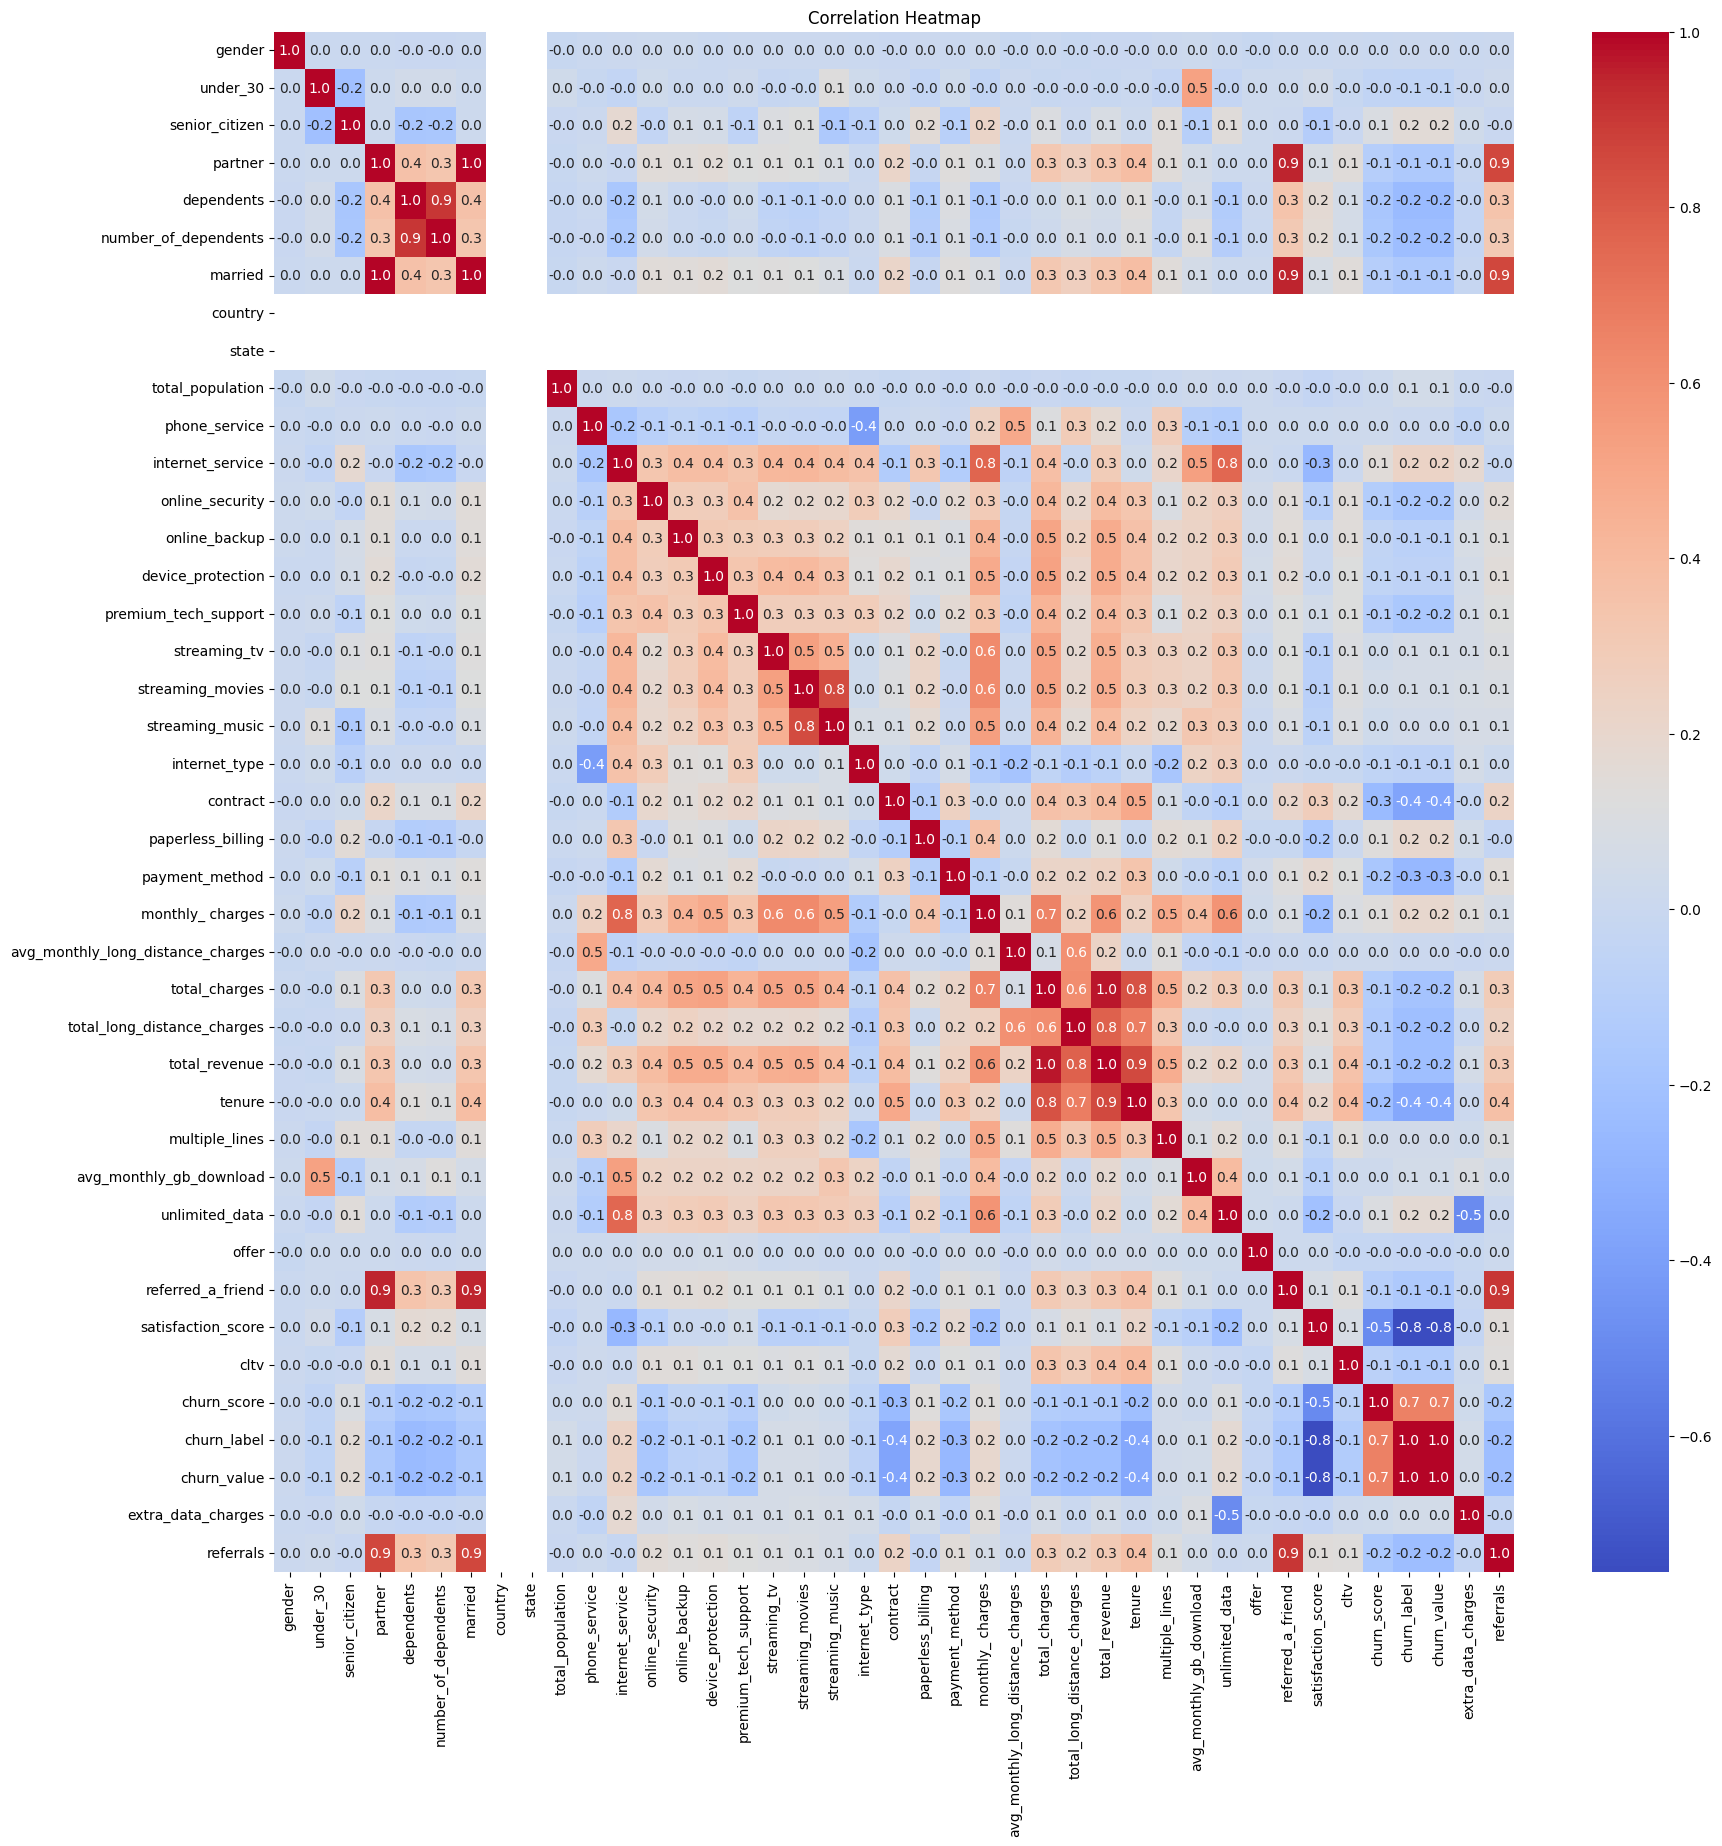

In [10]:
correlation_matrix = data.corr(method='pearson')

# Display the correlation matrix
# print("Correlation Matrix:\n", correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(20,20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
data

,gender,under_30,senior_citizen,partner,dependents,number_of_dependents,married,country,state,total_population,phone_service,internet_service,online_security,online_backup,device_protection,premium_tech_support,streaming_tv,streaming_movies,streaming_music,internet_type,contract,paperless_billing,payment_method,monthly_ charges,avg_monthly_long_distance_charges,total_charges,total_long_distance_charges,total_revenue,tenure,multiple_lines,avg_monthly_gb_download,unlimited_data,offer,referred_a_friend,satisfaction_score,cltv,churn_score,churn_label,churn_value,extra_data_charges,referrals
0,2,0,0,1,0,0,1,1,1,4498,1,1,0,1,0,1,1,0,0,3,3,1,2,65.60,42.39,593.30,381.51,974.81,9,0,16,1,2,1,3,2205,65,0,0,0,1
1,1,0,0,0,0,0,0,1,1,31297,1,1,0,0,0,0,0,1,1,3,1,0,2,59.90,10.69,542.40,96.21,610.28,9,1,10,0,2,0,5,5414,66,0,0,1,0
2,1,0,0,0,0,0,0,1,1,62069,1,1,0,0,1,0,0,0,0,1,1,1,1,73.90,33.65,280.85,134.60,415.45,4,0,30,1,2,0,1,4479,71,1,1,0,0
3,1,0,1,1,0,0,1,1,1,46677,1,1,0,1,1,0,1,1,0,1,1,1,1,98.00,27.82,1237.85,361.66,1599.51,13,0,4,1,3,1,1,3714,91,1,1,0,1
4,2,0,1,1,0,0,1,1,1,42853,1,1,0,0,0,1,1,0,0,1,1,1,2,83.90,7.38,267.40,22.14,289.54,3,0,11,1,3,1,1,3464,68,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2,1,0,0,0,0,0,1,1,44652,1,1,1,0,0,1,0,0,1,2,3,0,2,55.15,46.68,742.90,606.84,1349.74,13,0,59,1,3,0,4,3161,59,0,0,0,0
7039,1,0,0,1,0,0,1,1,1,16525,1,1,0,0,0,0,0,1,1,1,1,1,1,85.10,16.20,1873.70,356.40,2230.10,22,1,17,1,3,1,1,5248,68,1,1,0,1
7040,1,1,0,0,0,0,0,1,1,383,1,1,0,1,0,0,0,0,0,2,1,1,2,50.30,18.62,92.75,37.24,129.99,2,0,51,1,2,0,5,5870,33,0,0,0,0
7041,1,1,0,1,0,0,1,1,1,12173,1,1,1,0,1,1,0,1,1,3,2,0,2,67.85,2.12,4627.65,142.04,4769.69,67,0,58,1,4,1,3,4792,59,0,0,0,2


In [12]:
data.drop(['churn_label', 'churn_score', 'referred_a_friend', 'married', 'total_revenue', 'total_long_distance_charges', 'total_charges', 'state', 'country'], axis=1, inplace=True)
x = data.drop('churn_value', axis=1)
y = data['churn_value']

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=42)


In [16]:
rf_params = {
    'n_estimators':[100, 200, 500, 1000],
    'criterion':['gini', 'entropy', 'log_loss'],
    'max_depth':[3, 5, 7, 10],
    'min_samples_split':[5, 7, 9, 10],
    'min_samples_leaf':[3, 5, 7],
}

rf_model = RandomForestClassifier(random_state=42, verbose=1, n_jobs=-1)
best_rf_model = GridSearchCV(rf_model, rf_params, cv=5, scoring='accuracy')
best_rf_model.fit(x_train,y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(n_jobs=-1, random_state=42,
                                              verbose=1),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_leaf': [3, 5, 7],
                         'min_samples_split': [5, 7, 9, 10],
                         'n_estimators': [100, 200, 500, 1000]},
             scoring='accuracy')

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [18]:
y_pred = best_rf_model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 1000 out of 1000 | elapsed:    0.2s finished


In [19]:
cm

array([[1296,   12],
       [  69,  378]])

In [20]:
acc = accuracy_score(y_test, y_pred)

In [21]:
acc

0.9538461538461539

In [52]:
best_rf_model.best_estimator_

RandomForestClassifier(max_depth=10, min_samples_leaf=3, min_samples_split=10,
                       n_estimators=1000, n_jobs=-1, random_state=42,
                       verbose=1)

In [53]:
best_rf_model.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'min_samples_leaf': 3,
 'min_samples_split': 10,
 'n_estimators': 1000}

In [25]:
model = RandomForestClassifier(verbose=1, random_state=42, criterion='gini', max_depth=10, min_samples_leaf=3, min_samples_split=10,n_estimators=1000)
model.fit(x_train, y_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    1.5s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    2.5s


RandomForestClassifier(max_depth=10, min_samples_leaf=3, min_samples_split=10,
                       n_estimators=1000, random_state=42, verbose=1)

In [35]:
model.feature_importances_.tolist()
x.columns.tolist()
feature_imp = pd.DataFrame({'A':model.feature_importances_.tolist(),'B':x.columns.tolist()})

In [39]:
feature_imp.sort_values('A', ascending=False)

,A,B
29,0.563127,satisfaction_score
19,0.098050,contract
24,0.062591,tenure
22,0.033974,monthly_ charges
21,0.028709,payment_method
32,0.026345,referrals
26,0.020526,avg_monthly_gb_download
4,0.017083,dependents
5,0.016110,number_of_dependents
11,0.014042,online_security


In [55]:
info.update({'rf_best_params':best_rf_model.best_params_})

In [56]:
with open('note.json', 'w') as file:
    file.write(json.dumps(info))